<a href="https://colab.research.google.com/github/shindesai125/Deep-Learning/blob/main/Temperature_prediction_Deep_GRU_Deep_LSTM_Deep_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import mean_squared_error

In [3]:
from collections import UserList
url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
data= pd.read_csv(url)
values = data['Temp'].values.reshape(-1,1)

In [4]:
values

array([[20.7],
       [17.9],
       [18.8],
       ...,
       [13.5],
       [15.7],
       [13. ]])

In [5]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(values)

In [6]:
def create_sequences(dataset, time_steps=7):
    X, y = [], []
    for i in range(len(dataset)-time_steps):
        X.append(dataset[i:(i+time_steps), 0])
        y.append(dataset[i+time_steps, 0])
    return np.array(X), np.array(y)

In [7]:
time_steps = 7
X, y = create_sequences(scaled, time_steps)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [8]:
train_size = int(len(X)*0.8)
train_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [9]:
# SImpleRNN
model1 = Sequential()
model1.add(SimpleRNN(50, input_shape=(time_steps, 1)))
model1.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
from tensorflow.keras.losses import MeanSquaredError
model1.compile(optimizer= 'adam', loss = MeanSquaredError(), metrics=['mae'])

In [11]:
model1.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0169 - mae: 0.1017 - val_loss: 0.0083 - val_mae: 0.0715
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - mae: 0.0768 - val_loss: 0.0074 - val_mae: 0.0670
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091 - mae: 0.0753 - val_loss: 0.0089 - val_mae: 0.0756
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - mae: 0.0759 - val_loss: 0.0074 - val_mae: 0.0676
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - mae: 0.0766 - val_loss: 0.0074 - val_mae: 0.0678
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0090 - mae: 0.0749 - val_loss: 0.0074 - val_mae: 0.0674
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0088 - mae: 0.0738 - val_loss: 0.0073 - val_mae: 0.0676
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - mae: 0.0763 - val_loss: 0.0077 - val_mae: 0.0688
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.00

In [12]:
loss, mae = model1.evaluate(X_test, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 - mae: 0.0689


# ***Deep RNN***

In [13]:
# Deep SimpleRNN
model2 = Sequential()
model2.add(SimpleRNN(50, return_sequences=True, input_shape=(time_steps, 1)))
model2.add(SimpleRNN(50, input_shape=(time_steps, 1)))
model2.add(Dense(1, activation='linear'))

In [14]:
model2.compile(optimizer= 'adam', loss = MeanSquaredError(), metrics=['mae'])

In [15]:
model2.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0698 - mae: 0.1924 - val_loss: 0.0078 - val_mae: 0.0694
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093 - mae: 0.0768 - val_loss: 0.0075 - val_mae: 0.0678
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 - mae: 0.0763 - val_loss: 0.0077 - val_mae: 0.0696
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101 - mae: 0.0792 - val_loss: 0.0075 - val_mae: 0.0677
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - mae: 0.0800 - val_loss: 0.0074 - val_mae: 0.0672
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0099 - mae: 0.0792 - val_loss: 0.0073 - val_mae: 0.0672
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093 - mae: 0.0764 - val_loss: 0.0074 - val_mae: 0.0680
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097 - mae: 0.0780 - val_loss: 0.0073 - val_mae: 0.0672
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.00

In [16]:
# LSTM
model3 = Sequential()
model3.add(LSTM(50, input_shape=(time_steps, 1)))
model3.add(Dense(1, activation='linear'))

In [17]:
model3.compile(optimizer= 'adam', loss = MeanSquaredError(), metrics=['mae'])

In [18]:
model3.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0636 - mae: 0.1898 - val_loss: 0.0103 - val_mae: 0.0795
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0120 - mae: 0.0865 - val_loss: 0.0098 - val_mae: 0.0776
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0117 - mae: 0.0841 - val_loss: 0.0096 - val_mae: 0.0767
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0112 - mae: 0.0827 - val_loss: 0.0094 - val_mae: 0.0755
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0113 - mae: 0.0836 - val_loss: 0.0092 - val_mae: 0.0748
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0111 - mae: 0.0820 - val_loss: 0.0091 - val_mae: 0.0743
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0112 - mae: 0.0832 - val_loss: 0.0089 - val_mae: 0.0737
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0109 - mae: 0.0810 - val_loss: 0.0087 - val_mae: 0.0729
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.010

In [19]:
# LSTM
model4 = Sequential()
model4.add(LSTM(50, return_sequences=True, input_shape=(time_steps, 1)))
model4.add(LSTM(50, input_shape=(time_steps, 1)))
model4.add(Dense(1, activation='linear'))

In [20]:
model4.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [21]:
model4.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0602 - mae: 0.1816 - val_loss: 0.0113 - val_mae: 0.0832
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0128 - mae: 0.0888 - val_loss: 0.0104 - val_mae: 0.0798
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0126 - mae: 0.0881 - val_loss: 0.0103 - val_mae: 0.0795
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0118 - mae: 0.0858 - val_loss: 0.0101 - val_mae: 0.0789
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0127 - mae: 0.0886 - val_loss: 0.0099 - val_mae: 0.0778
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0116 - mae: 0.0840 - val_loss: 0.0095 - val_mae: 0.0762
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0112 - mae: 0.0839 - val_loss: 0.0095 - val_mae: 0.0760
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0118 - mae: 0.0850 - val_loss: 0.0088 - val_mae: 0.0732
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.01

In [22]:
# GRU
model5 = Sequential()
model5.add(GRU(50, input_shape=(time_steps, 1)))
model5.add(Dense(1, activation='linear'))

In [23]:
model5.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [24]:
model5.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0361 - mae: 0.1432 - val_loss: 0.0095 - val_mae: 0.0767
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0106 - mae: 0.0797 - val_loss: 0.0086 - val_mae: 0.0726
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0111 - mae: 0.0821 - val_loss: 0.0082 - val_mae: 0.0710
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0100 - mae: 0.0777 - val_loss: 0.0080 - val_mae: 0.0700
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 - mae: 0.0762 - val_loss: 0.0077 - val_mae: 0.0689
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0093 - mae: 0.0755 - val_loss: 0.0083 - val_mae: 0.0719
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095 - mae: 0.0767 - val_loss: 0.0079 - val_mae: 0.0707
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - mae: 0.0761 - val_loss: 0.0074 - val_mae: 0.0676
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.009

In [25]:
# GRU
model6 = Sequential()
model6.add(GRU(50, return_sequences=True, input_shape=(time_steps, 1)))
model6.add(GRU(50, input_shape=(time_steps, 1)))
model6.add(Dense(1, activation='linear'))

In [26]:
model6.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [27]:
model6.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0536 - mae: 0.1697 - val_loss: 0.0109 - val_mae: 0.0820
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0116 - mae: 0.0843 - val_loss: 0.0093 - val_mae: 0.0754
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0110 - mae: 0.0822 - val_loss: 0.0088 - val_mae: 0.0735
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0104 - mae: 0.0792 - val_loss: 0.0084 - val_mae: 0.0717
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0102 - mae: 0.0786 - val_loss: 0.0077 - val_mae: 0.0687
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0094 - mae: 0.0758 - val_loss: 0.0075 - val_mae: 0.0679
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0092 - mae: 0.0743 - val_loss: 0.0075 - val_mae: 0.0680
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0088 - mae: 0.0731 - val_loss: 0.0074 - val_mae: 0.0674
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


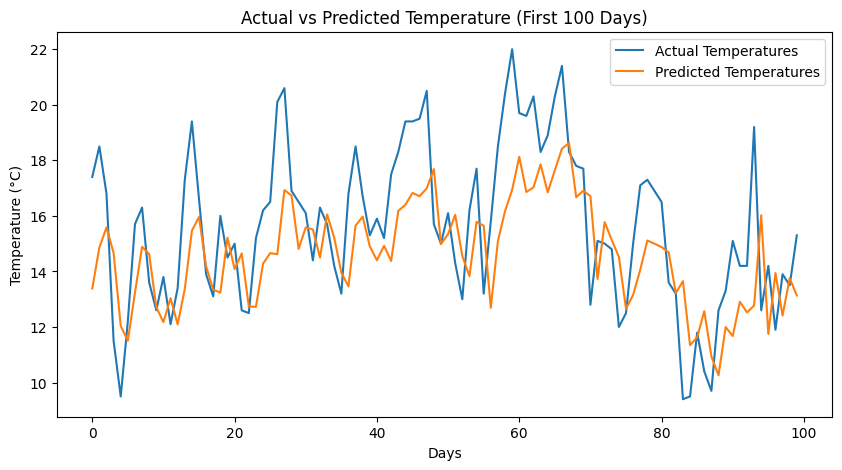

---------------------------------------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


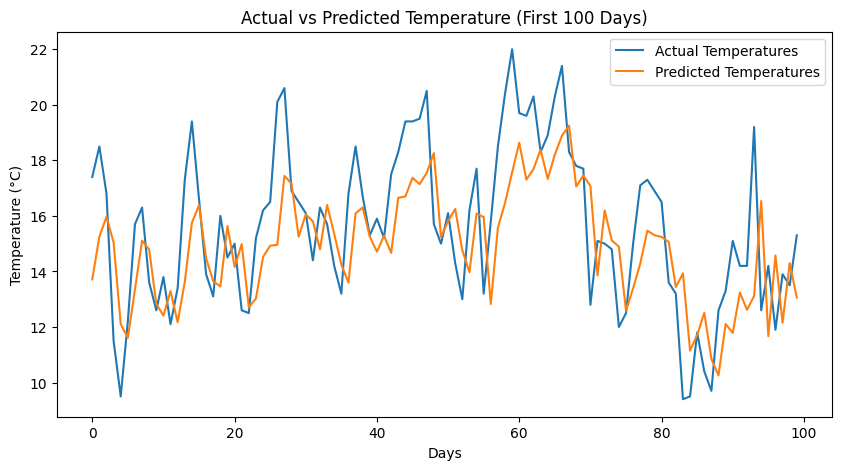

---------------------------------------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


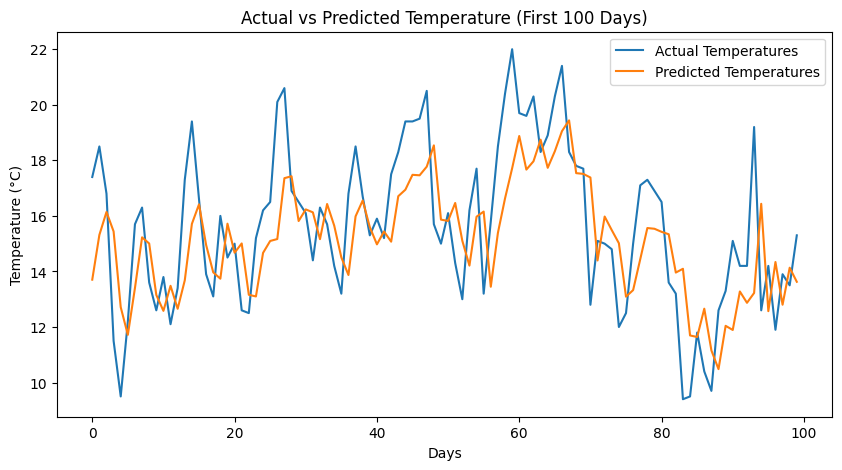

---------------------------------------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


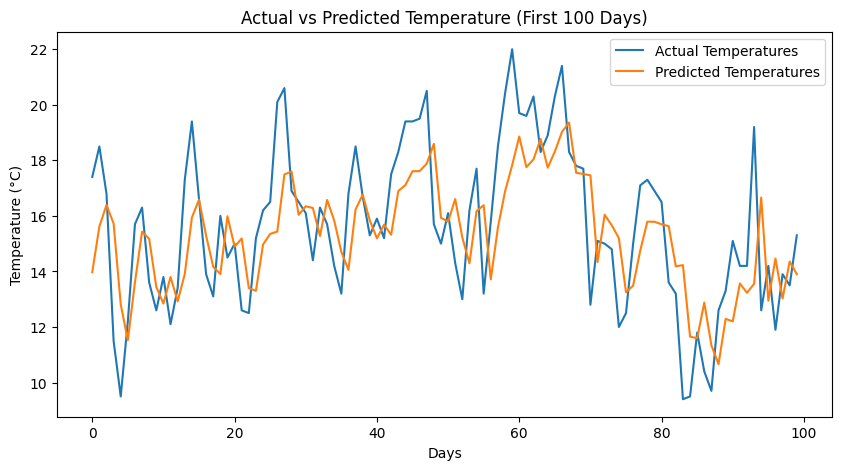

---------------------------------------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


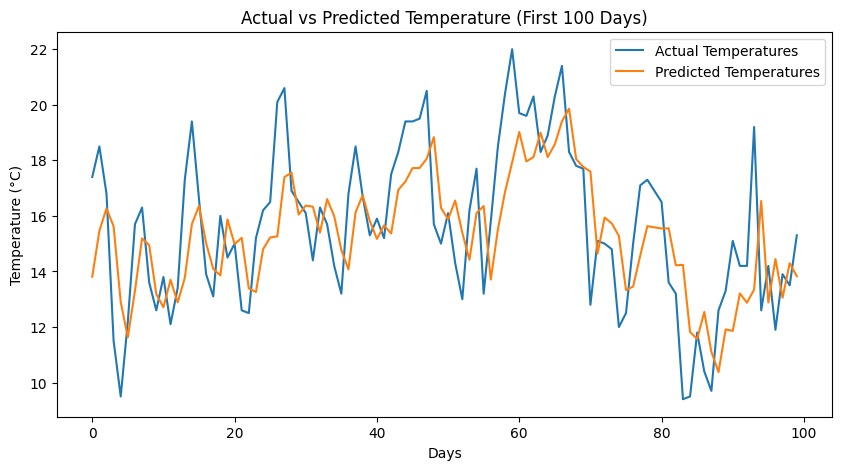

---------------------------------------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


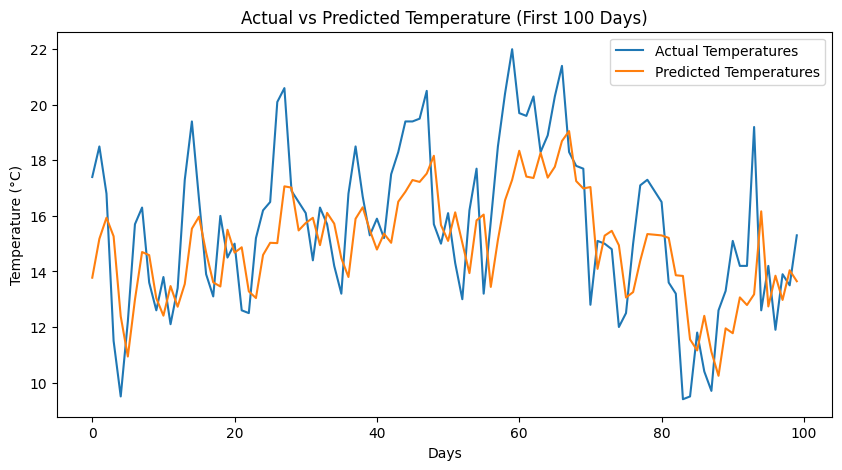

In [35]:
import matplotlib.pyplot as plt
# Predict on test data
y_pred = model1.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual1 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual1[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print('---------------------------------------------------------------')

# Predict on test data
y_pred = model2.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual2 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual2[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print('---------------------------------------------------------------')


# Predict on test data
y_pred = model3.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual3 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual3[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print('---------------------------------------------------------------')


# Predict on test data
y_pred = model4.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual4 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual4[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print('---------------------------------------------------------------')


# Predict on test data
y_pred = model5.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual5 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual5[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print('---------------------------------------------------------------')


# Predict on test data
y_pred = model6.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual6 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual6[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


In [31]:
from tensorflow.keras.layers import Dropout

model7 = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='linear')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model7.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [33]:
model7.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0625 - mae: 0.1892 - val_loss: 0.0110 - val_mae: 0.0824
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0139 - mae: 0.0925 - val_loss: 0.0105 - val_mae: 0.0802
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0135 - mae: 0.0917 - val_loss: 0.0118 - val_mae: 0.0857
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0145 - mae: 0.0944 - val_loss: 0.0105 - val_mae: 0.0804
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0129 - mae: 0.0902 - val_loss: 0.0100 - val_mae: 0.0783
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0128 - mae: 0.0896 - val_loss: 0.0098 - val_mae: 0.0774
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0128 - mae: 0.0883 - val_loss: 0.0099 - val_mae: 0.0782
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0133 - mae: 0.0905 - val_loss: 0.0095 - val_mae: 0.0761
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


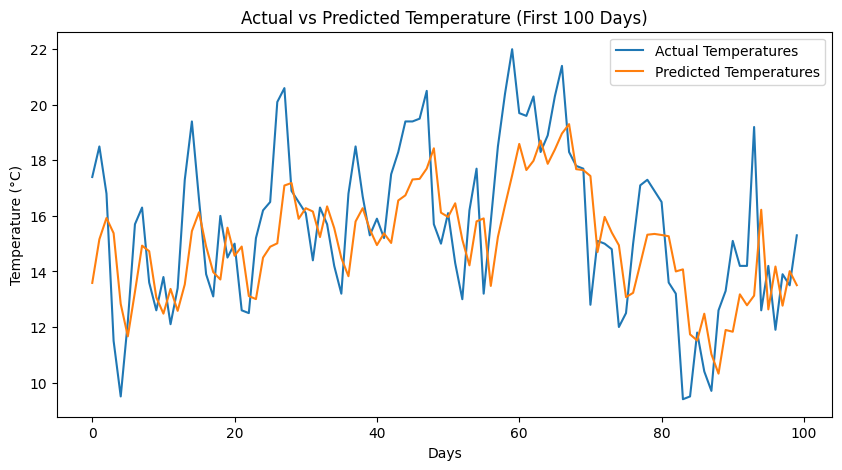

In [36]:
# Predict on test data
y_pred = model7.predict(X_test)  # Example: model4 is your LSTM
# Inverse scale back to original temperature
y_pred_actual7 = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], label='Actual Temperatures')
plt.plot(y_pred_actual7[:100], label='Predicted Temperatures')
plt.title('Actual vs Predicted Temperature (First 100 Days)')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

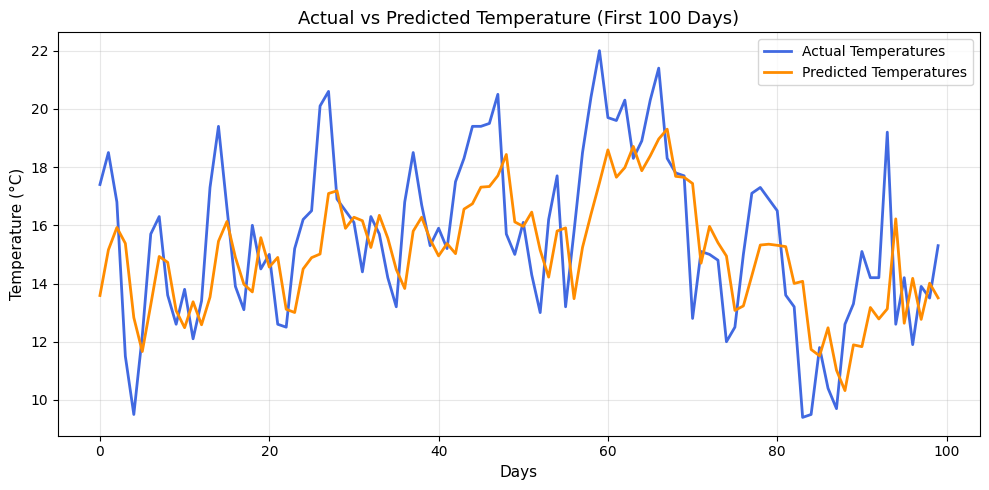

In [37]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:100], color='royalblue', label='Actual Temperatures', linewidth=2)
plt.plot(y_pred_actual7[:100], color='darkorange', label='Predicted Temperatures', linewidth=2)
plt.title('Actual vs Predicted Temperature (First 100 Days)', fontsize=13)
plt.xlabel('Days', fontsize=11)
plt.ylabel('Temperature (°C)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
recent_temps = [14.5, 15.0, 18.2, 53.8, 14.0, 15.6, 13.9]  # example data
recent_scaled=scaler.transform(np.array(recent_temps).reshape(-1,1))

recent_scaled=recent_scaled.reshape(1,7,1)

next_day_scaled=model7.predict(recent_scaled)

next_day_temp=scaler.inverse_transform(next_day_scaled)

print(f"The next day's temperature is: {next_day_temp[0][0]:.2f}°C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The next day's temperature is: 15.34°C


In [41]:
import numpy as np

# Step 1: Take 7 temperature inputs from the user
recent_temps = []
print("Enter the temperatures for the last 7 days (in °C):")
for i in range(7):
    temp = float(input(f"Day {i+1} temperature: "))
    recent_temps.append(temp)

# Step 2: Convert and scale using the same MinMaxScaler used in training
recent_scaled = scaler.transform(np.array(recent_temps).reshape(-1, 1))

# Step 3: Reshape for model input -> (samples=1, timesteps=7, features=1)
recent_scaled = recent_scaled.reshape(1, 7, 1)

# Step 4: Predict next day temperature (normalized)
next_day_scaled = model7.predict(recent_scaled)

# Step 5: Inverse transform to get actual temperature
next_day_temp = scaler.inverse_transform(next_day_scaled)

print("\n🌤️ Predicted temperature for tomorrow:", round(next_day_temp[0][0], 2), "°C")


Enter the temperatures for the last 7 days (in °C):
Day 1 temperature: 15
Day 2 temperature: 100
Day 3 temperature: 22.55
Day 4 temperature: 13.4
Day 5 temperature: 38.5
Day 6 temperature: 32.7
Day 7 temperature: 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

🌤️ Predicted temperature for tomorrow: 18.19 °C
